# Indian Household Finance Segmentation  
**Unsupervised Clustering of Credit-Difficulty Households using the India Human Development Survey II (IHDS-II, 2011–12)**

## Overview

This project applies unsupervised machine learning (K-Means clustering + PCA) to the **India Human Development Survey II (IHDS-II)** — a nationally representative survey of 42,152 Indian households — to identify distinct financial profiles among households that reported **difficulty obtaining credit**.

### Notebook organization
- **Section 1**: Exploratory Data Analysis (age, education, urban/rural, consumption, asset–debt correlations)  
- **Section 2**: Two-feature K-Means clustering (`DEBT` vs `ASSETS`) with elbow & silhouette evaluation  
- **Section 3**: Multi-feature clustering pipeline (trimmed variance + StandardScaler + PCA)  
- **Section 4**: Fully interactive Plotly Dash web application (live radio button + slider controls)


**Dataset**: IHDS-II Household File (ICPSR 36151) – free, publicly available data (https://www.icpsr.umich.edu/web/DSDR/studies/36151)

**Covered in the project**: pandas wrangling, feature engineering (trimmed variance), K-Means, PCA, interactive Dash deployment, reproducible pipelines.

## 1: Exploring the Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df_check = pd.read_csv("data/IHDS_II_household.tsv", sep="\t", low_memory=False, nrows=5)
print(df_check.columns.tolist())
print(df_check.head())

['SURVEY', 'STATEID', 'DISTID', 'PSUID', 'HHID', 'HHSPLITID', 'IDPSU', 'IDHH', 'WT', 'INDWT', 'FWT', 'INDFWT', 'DIST01', 'DISTRICT', 'HS3D', 'HS3M', 'HS3Y', 'HS3DATE', 'HS4A', 'HS4B', 'HS4C', 'ID11', 'ID12ANM', 'ID12BNM', 'ID13', 'GROUPS', 'ID14', 'ID14NM', 'ID15', 'ID16', 'ID17', 'ID18A', 'ID18ANM', 'ID18B', 'ID18BNM', 'ID18C', 'MG1', 'FM1', 'FM2', 'FM3', 'FM4A', 'FM4B', 'FM4C', 'FM5A', 'FM5B', 'FM5C', 'FM6A', 'FM6B', 'FM6C', 'FM7A', 'FM7B', 'FM7C', 'FM8A', 'FM9A', 'FM10A', 'FM10B', 'FM10C', 'FM11A', 'FM11B', 'FM11C', 'FM12A', 'FM12B', 'FM12C', 'FM13A', 'FM13B', 'FM14A', 'FM14B', 'FM14C', 'FM14D', 'FM15A', 'FM15B', 'FM26A', 'FM26B', 'FM26C', 'FM27A', 'FM27B', 'FM27C', 'FM28A', 'FM28B', 'FM29', 'FM30', 'FM31', 'FM32', 'FM33', 'FM34', 'FM39A', 'FM39B', 'FM39C1', 'FM39C2', 'FM39C3', 'FM40A', 'FM40B', 'FM40C', 'FM40D', 'FM40E', 'FM40F', 'FM40G', 'FM40H', 'FM40I', 'FM40J', 'FM40K', 'FM41A', 'FM41B', 'FM41C', 'FM41D', 'AN1', 'AN1A', 'AN1B', 'AN1C', 'AN1D', 'AN1E', 'AN1F', 'AN1G', 'AN2A', 'A

In [3]:
df = pd.read_csv("data/IHDS_II_household.tsv", sep="\t", low_memory=False)
print("df type:", type(df))
print("df shape:", df.shape)
df.head()

df type: <class 'pandas.core.frame.DataFrame'>
df shape: (42152, 758)


,SURVEY,STATEID,DISTID,PSUID,HHID,HHSPLITID,IDPSU,IDHH,WT,INDWT,...,NWKANY5,INCNONAG,INCAGLAB,INCSALARY,INCNREGA,INCNONNREGA,NNR,HHEDUC,HHEDUCM,HHEDUCF
0,2,1,2,1,10,1,10201,102010101,3687.926308,33191.336768,...,3,30000,0,137200,0,30000,0,9,9,8
1,2,1,2,1,20,1,10201,102010201,3687.926308,59006.820921,...,5,0,0,1015300,0,0,0,16,16,12
2,2,1,2,1,30,1,10201,102010301,3687.926308,25815.484153,...,2,0,0,192000,0,0,0,11,10,11
3,2,1,2,1,40,1,10201,102010401,3687.926308,18439.631538,...,2,80600,0,0,0,80600,0,0,0,0
4,2,1,2,1,50,1,10201,102010501,3687.926308,36879.263076,...,2,113400,0,0,0,113400,0,9,9,8


In [4]:
# Inspect all debt-related columns to find the borrowing-difficulty flag
debt_cols = [col for col in df.columns if col.startswith("DB")]
print("Debt columns found:", debt_cols)

for col in debt_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index().head(15))  # shows codes + counts

Debt columns found: ['DB1', 'DB1A', 'DB1B', 'DB1C', 'DB1D', 'DB1E', 'DB1F', 'DB2', 'DB2A', 'DB2B', 'DB2C', 'DB2CNM', 'DB2D', 'DB2DNM', 'DB2E', 'DB2F', 'DB2G', 'DB3', 'DB4A', 'DB4B', 'DB5', 'DB6', 'DB6A', 'DB7', 'DB8A', 'DB8B', 'DB8C', 'DB8D', 'DB8E', 'DB8F', 'DB9A', 'DB9B', 'DB9C', 'DB9D', 'DB9E', 'DB9F', 'DB9G', 'DB9H', 'DB9I']

--- DB1 ---
DB1
        28
0    19494
1    22630
Name: count, dtype: int64

--- DB1A ---
DB1A
        28
0    32950
1     9174
Name: count, dtype: int64

--- DB1B ---
DB1B
        28
0    38079
1     4045
Name: count, dtype: int64

--- DB1C ---
DB1C
        28
0    35762
1     6362
Name: count, dtype: int64

--- DB1D ---
DB1D
        28
0    40764
1     1360
Name: count, dtype: int64

--- DB1E ---
DB1E
        28
0    31299
1    10825
Name: count, dtype: int64

--- DB1F ---
DB1F
        31
0    41378
1      743
Name: count, dtype: int64

--- DB2 ---
DB2
         74
0     19500
1      8784
10      410
11       28
12      136
13        9
14        7
15      157


In [7]:
# === CREDIT-DIFFICULTY ===
# DB8A–F = loan application outcome from 6 sources (bank, MFI, moneylender, etc.)
# 1 = did not apply
# 2 = applied but DID NOT GET IT  ← our flag
# 3 = applied and got it

db8_cols = ["DB8A", "DB8B", "DB8C", "DB8D", "DB8E", "DB8F"]

# Numeric conversion (to fixes the object/string issue)
for col in db8_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("After numeric conversion — value counts for each DB8 source:")
for col in db8_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).sort_index())

# Create the binary flag (any source = 2 → credit difficulty)
df["CREDIT_DIFFICULTY"] = df[db8_cols].eq(2).any(axis=1).astype(int)

print("\nCREDIT_DIFFICULTY value counts:")
print(df["CREDIT_DIFFICULTY"].value_counts())
print("Households with credit difficulty:", df["CREDIT_DIFFICULTY"].sum())

After numeric conversion — value counts for each DB8 source:

DB8A:
DB8A
1.0    31739
2.0     1200
3.0     9174
NaN       39
Name: count, dtype: int64

DB8B:
DB8B
1.0    36574
2.0     1495
3.0     4045
NaN       38
Name: count, dtype: int64

DB8C:
DB8C
1.0    34243
2.0     1510
3.0     6362
NaN       37
Name: count, dtype: int64

DB8D:
DB8D
1.0    39034
2.0     1721
3.0     1360
NaN       37
Name: count, dtype: int64

DB8E:
DB8E
1.0    29688
2.0     1602
3.0    10825
NaN       37
Name: count, dtype: int64

DB8F:
DB8F
1.0    39572
2.0     1798
3.0      743
NaN       39
Name: count, dtype: int64

CREDIT_DIFFICULTY value counts:
CREDIT_DIFFICULTY
0    38821
1     3331
Name: count, dtype: int64
Households with credit difficulty: 3331


In [8]:
mask = df["CREDIT_DIFFICULTY"] == 1
df_credit = df[mask].copy()

print("df_credit type:", type(df_credit))
print("df_credit shape:", df_credit.shape)
df_credit.head()

df_credit type: <class 'pandas.core.frame.DataFrame'>
df_credit shape: (3331, 759)


,SURVEY,STATEID,DISTID,PSUID,HHID,HHSPLITID,IDPSU,IDHH,WT,INDWT,...,INCNONAG,INCAGLAB,INCSALARY,INCNREGA,INCNONNREGA,NNR,HHEDUC,HHEDUCM,HHEDUCF,CREDIT_DIFFICULTY
8,2,1,2,1,90,1,10201,102010901,3687.926308,29503.410461,...,0,0,161760,0,0,0,9,9,0,1
9,2,1,2,1,90,2,10201,102010902,3687.926308,14751.705230,...,25420,0,0,0,25420,0,0,0,0,1
45,2,1,2,3,50,1,10203,102030501,3687.926157,22127.556939,...,0,0,368820,0,0,0,15,15,0,1
51,2,1,2,3,100,1,10203,102031001,3687.926157,33191.335409,...,1572,27900,0,1572,0,0,9,9,0,1
58,2,1,2,3,160,1,10203,102031601,3687.926157,18439.630783,...,0,0,0,0,0,0,11,11,9,1


### Age group exploration

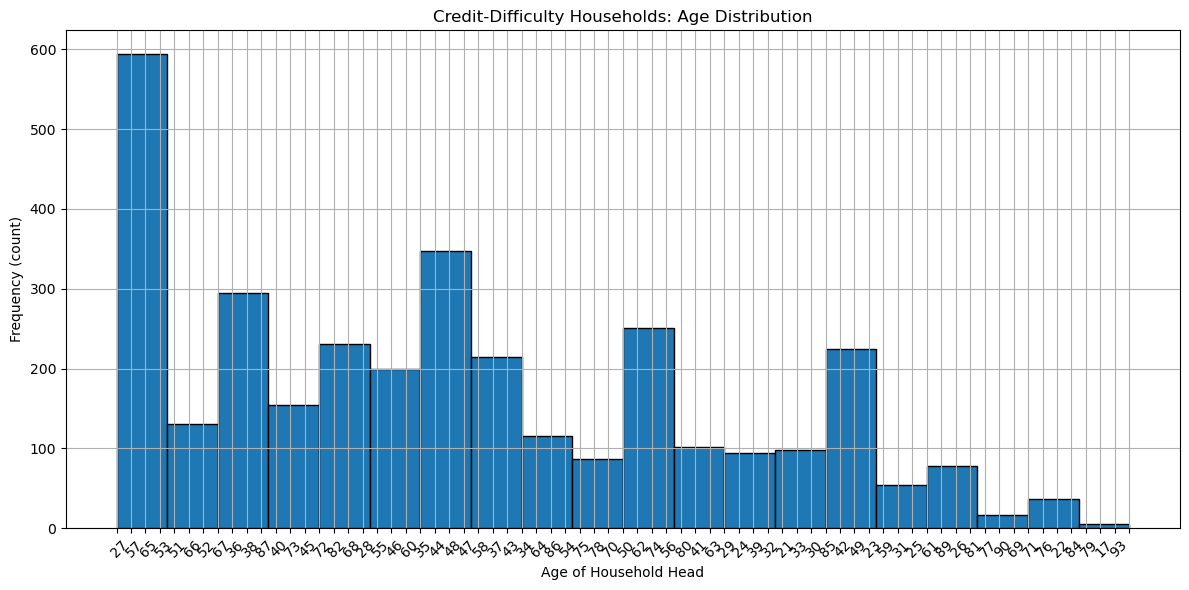

In [11]:
plt.figure(figsize=(12, 6))                    
df_credit["MHEADAGE"].hist(bins=20, edgecolor="black")   
plt.xlabel("Age of Household Head")
plt.ylabel("Frequency (count)")
plt.title("Credit-Difficulty Households: Age Distribution")
plt.xticks(rotation=45, ha="right")           
plt.tight_layout()
plt.show()

In [12]:
df["MHEADAGE"] = pd.to_numeric(df["MHEADAGE"], errors="coerce")
df_credit = df[df["CREDIT_DIFFICULTY"] == 1].copy()   

print("MHEADAGE dtype:", df_credit["MHEADAGE"].dtype)
print("Missing ages in credit-difficulty group:", df_credit["MHEADAGE"].isna().sum())

MHEADAGE dtype: float64
Missing ages in credit-difficulty group: 423


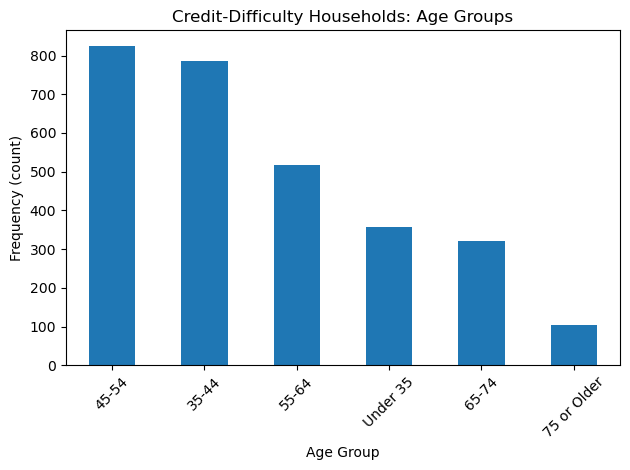

In [13]:
bins = [0, 35, 45, 55, 65, 75, 120]
labels_age = ["Under 35", "35-44", "45-54", "55-64", "65-74", "75 or Older"]
age_cl = pd.cut(df_credit["MHEADAGE"], bins=bins, labels=labels_age, right=False)

age_value_counts = age_cl.value_counts()
age_value_counts.plot(
    kind="bar",
    xlabel="Age Group",
    ylabel="Frequency (count)",
    title="Credit-Difficulty Households: Age Groups"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print("DB5 (total debt) dtype:", df["DB5"].dtype)
print("ASSETS dtype:", df["ASSETS"].dtype)
print("Any non-numeric in key columns?\n",
      df[["MHEADAGE", "DB5", "ASSETS", "COPC", "INCOME", "NPERSONS", "HHEDUC", "URBAN2011"]].dtypes)

DB5 (total debt) dtype: object
ASSETS dtype: object
Any non-numeric in key columns?
 MHEADAGE     float64
DB5           object
ASSETS        object
COPC          object
INCOME       float64
NPERSONS       int64
HHEDUC        object
URBAN2011      int64
dtype: object


In [16]:
# === GLOBAL NUMERIC CLEANUP ===
numeric_cols = [
    "ASSETS", "DB5", "COPC", 
    "HHEDUC"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("All key columns converted to numeric!")
print("\nNew dtypes:")
print(df[numeric_cols].dtypes)

# Recreate the credit-difficulty subset with clean data
df_credit = df[df["CREDIT_DIFFICULTY"] == 1].copy()
print("\ndf_credit shape:", df_credit.shape)

All key columns converted to numeric!

New dtypes:
ASSETS    float64
DB5       float64
COPC      float64
HHEDUC    float64
dtype: object

df_credit shape: (3331, 759)


### Education level exploration

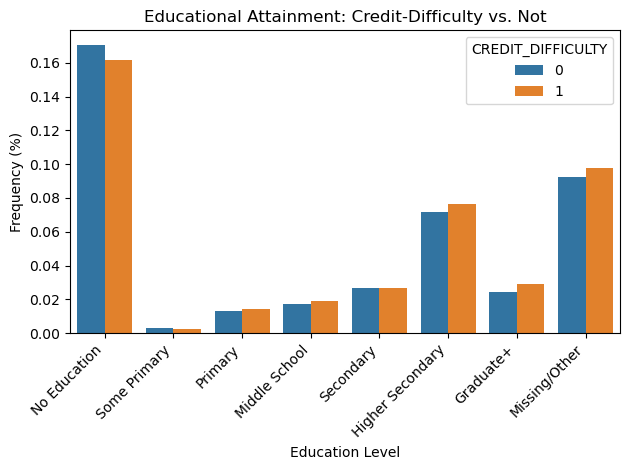

In [17]:
educ_dict = {
    0: "No Education", 1: "Some Primary", 2: "Primary",
    3: "Middle School", 4: "Secondary", 5: "Higher Secondary",
    6: "Graduate+", 9: "Missing/Other"   
}

educ_credit = df_credit["HHEDUC"].replace(educ_dict)
educ_all = df["HHEDUC"].replace(educ_dict)
educ_order = list(educ_dict.values())

df_educ = (
    df["HHEDUC"]
    .replace(educ_dict)
    .groupby(df["CREDIT_DIFFICULTY"])
    .value_counts(normalize=True)
    .rename("frequency")
    .to_frame()
    .reset_index()
)

sns.barplot(
    x="HHEDUC",
    y="frequency",
    hue="CREDIT_DIFFICULTY",
    data=df_educ,
    order=educ_order
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Education Level")
plt.ylabel("Frequency (%)")
plt.title("Educational Attainment: Credit-Difficulty vs. Not")
plt.tight_layout()
plt.show()

### Urban vs Rural breakdown

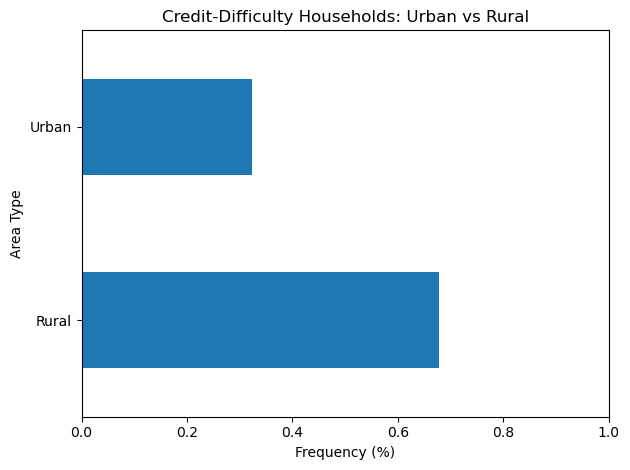

In [18]:
urban_dict = {0: "Rural", 1: "Urban"}
urban_counts = df_credit["URBAN2011"].replace(urban_dict).value_counts(normalize=True)
urban_counts.plot(kind="barh")
plt.xlim((0, 1))
plt.xlabel("Frequency (%)")
plt.ylabel("Area Type")
plt.title("Credit-Difficulty Households: Urban vs Rural")
plt.tight_layout()
plt.show()

### Consumption category comparison

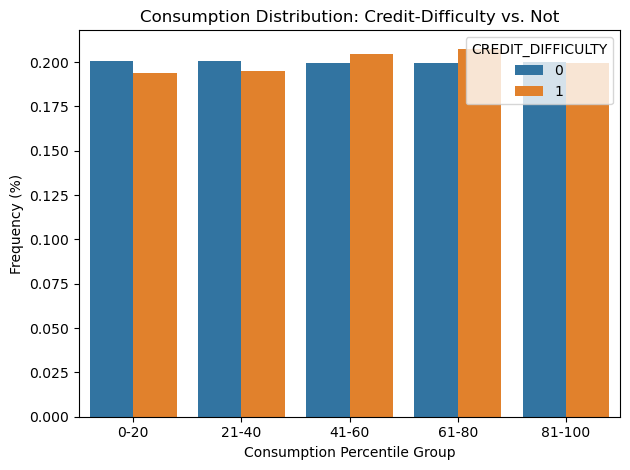

In [19]:
df["COPC_CAT"] = pd.qcut(df["COPC"], q=5, labels=["0-20", "21-40", "41-60", "61-80", "81-100"])

df_copc = (
    df["COPC_CAT"]
    .groupby(df["CREDIT_DIFFICULTY"])
    .value_counts(normalize=True)
    .rename("frequency")
    .to_frame()
    .reset_index()
)

sns.barplot(
    x="COPC_CAT",
    y="frequency",
    hue="CREDIT_DIFFICULTY",
    data=df_copc,
    order=["0-20", "21-40", "41-60", "61-80", "81-100"]
)
plt.xlabel("Consumption Percentile Group")
plt.ylabel("Frequency (%)")
plt.title("Consumption Distribution: Credit-Difficulty vs. Not")
plt.tight_layout()
plt.show()

### Asset vs Debt correlation

In [20]:
asset_debt_corr_all = df["ASSETS"].corr(df["DB5"])
print("ASSETS vs DEBT (DB5) correlation:", round(asset_debt_corr_all, 3))

asset_debt_corr_credit = df_credit["ASSETS"].corr(df_credit["DB5"])
print("Credit-Difficulty — ASSETS vs DEBT (DB5) correlation:", round(asset_debt_corr_credit, 3))

ASSETS vs DEBT (DB5) correlation: 0.155
Credit-Difficulty — ASSETS vs DEBT (DB5) correlation: 0.148


In [21]:
# Correlation matrices
cols = ["ASSETS", "INCOME", "DB5", "COPC", "NPERSONS"]   # NPERSONS = household size

corr_all = df[cols].corr()
print("Full Dataset Correlation Matrix:")
display(corr_all.style.background_gradient(axis=None))

corr_credit = df_credit[cols].corr()
print("Credit-Difficulty Subset Correlation Matrix:")
display(corr_credit.style.background_gradient(axis=None))

Full Dataset Correlation Matrix:


,ASSETS,INCOME,DB5,COPC,NPERSONS
ASSETS,1.000000,0.403075,0.155332,0.394649,0.101691
INCOME,0.403075,1.000000,0.190726,0.294540,0.156384
DB5,0.155332,0.190726,1.000000,0.198498,0.048424
COPC,0.394649,0.294540,0.198498,1.000000,-0.187426
NPERSONS,0.101691,0.156384,0.048424,-0.187426,1.000000


Credit-Difficulty Subset Correlation Matrix:


,ASSETS,INCOME,DB5,COPC,NPERSONS
ASSETS,1.000000,0.419111,0.147906,0.327021,0.086265
INCOME,0.419111,1.000000,0.151000,0.230644,0.141446
DB5,0.147906,0.151000,1.000000,0.134076,0.068012
COPC,0.327021,0.230644,0.134076,1.000000,-0.180182
NPERSONS,0.086265,0.141446,0.068012,-0.180182,1.000000


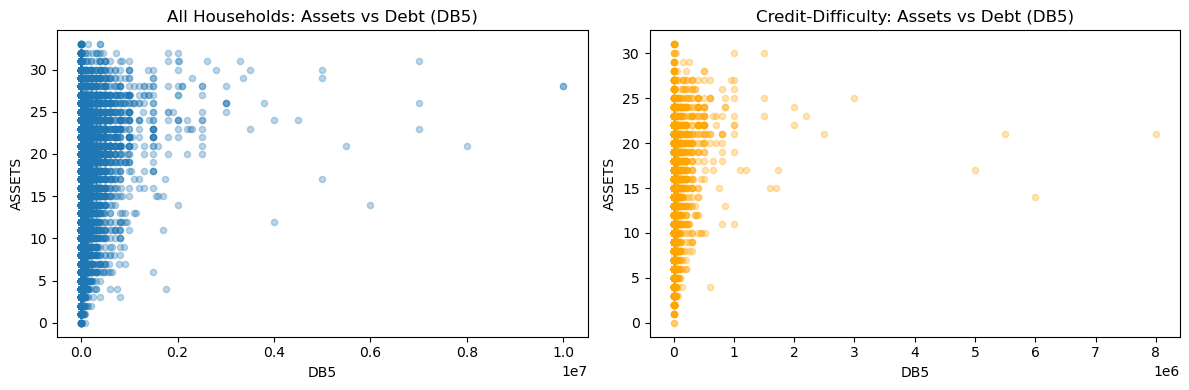

In [22]:
# Scatter: Assets vs Debt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.plot.scatter(x="DB5", y="ASSETS", ax=axes[0], alpha=0.3)
axes[0].set_title("All Households: Assets vs Debt (DB5)")

df_credit.plot.scatter(x="DB5", y="ASSETS", ax=axes[1], alpha=0.3, color="orange")
axes[1].set_title("Credit-Difficulty: Assets vs Debt (DB5)")

plt.tight_layout()
plt.show()

> This section painted a clear picture of who struggles to access credit in India.
Credit-difficulty households (3,331 HHs who applied but did not get loans) skew younger, are predominantly rural, and are concentrated in the lower consumption quintiles. Debt and assets are more tightly linked in this group than in the general population.